In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

In [3]:
X,y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [5]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train,y_train)

random_forest_model = RandomForestClassifier()
random_forest_model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
logistic_predictions = logistic_model.predict(X_test)
random_forest_predictions = random_forest_model.predict(X_test)

In [ ]:
test_df = pd.DataFrame(
    {
        "True":y_test,
        "logistic":logistic_predictions,
        "random_forest":random_forest_predictions
    }
)

In [11]:
test_df.head()

,True,logistic,random_forest
0,1,1,1
1,1,1,1
2,1,0,0
3,1,1,1
4,1,1,1


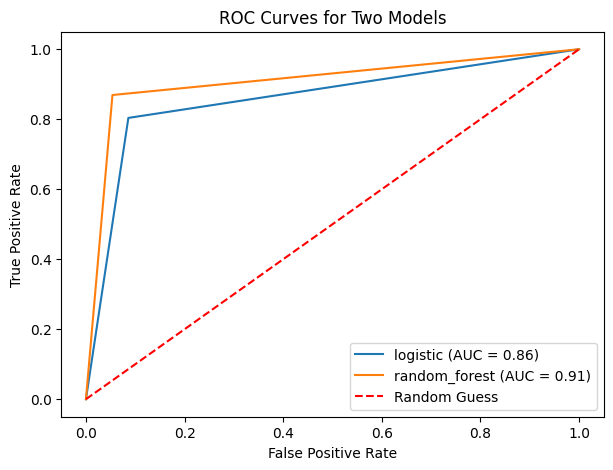

In [14]:
plt.figure(figsize=(7,5))

for model in ["logistic","random_forest"]:
    fpr, tpr, _ = roc_curve(test_df["True"], test_df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "r--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Two Models")
plt.legend()
plt.show()